# XPCS scan 263: prepare the hysteresis branch

41 states, 20 Marana frames per state, approximately 710.49 eV. Keep acquisition order, including repeated currents if more scans are added. Currents remain in amperes. Stream frame means, optionally subtract matching darks, divide by exposure, center, crop, then sum detector bins. **No dark files means no dark subtraction or guessed offset.** Detector masks are conservative; object supports use the existing library's geometry transformation.

The aperture coordinates are the `s2402_D1` starting geometry from the supplied legacy notebook. Inspect the overlay and edit them or supply a full-grid mask before interpreting quantitative results. The center was estimated from the scan-263 ring pattern; the beamstop/wire mask is an editable starting mask, not a calibrated detector map.

Optional alignment uses masked cross-correlation against one acquisition, refined to subpixel shifts on raw exposure-normalized intensities. Set `ALIGN_HOLOGRAMS=True` to try it. Shifts are applied together with centering, before crop/binning, with conservative mask propagation. Choose a stable-pattern ROI if magnetic contrast changes affect registration. Inspect the saved shifts and correlation scores before retrieval; enabling alignment rewrites the preprocessing cache.


In [26]:
from pathlib import Path
import sys, json
import numpy as np
import h5py
import matplotlib.pyplot as plt
HERE = Path.cwd()
if HERE.name != "2601_XPCS": HERE = HERE / "2601_XPCS"
if not (HERE / "reconstruction_inputs.py").is_file(): raise FileNotFoundError("Run from repository root or 2601_XPCS")
sys.path.insert(0, str(HERE)); sys.path.insert(0, str(HERE.parent))
import reconstruction_inputs as inputs

RAW_ROOT = Path("/media/riccardo/EXT_16TB1/DATA/P04/2601_XPCS/raw")
SCANS = [263]
DARK_SCANS = [262]  # Add matching dark scan numbers when available.
DARK_FILES = []  # Or explicit Marana .nx files; listed missing files raise an error.
DETECTOR_CENTER = (1105.50, 995.31)  # Raw (row, column), estimated from rings.
CROP = 0 # Remove this many raw detector pixels at each edge, before binning.
BINNING = 1
ALIGN_HOLOGRAMS = True
ALIGNMENT_REFERENCE = 39  # Acquisition-list index, not scan point number.
ALIGNMENT_MAX_SHIFT = 10.  # Maximum absolute correction per axis, raw detector pixels.
ALIGNMENT_UPSAMPLE_FACTOR = 20  # Subpixel optimizer tolerance: 1/20 raw pixel, not guaranteed accuracy.
ALIGNMENT_ROI = (1000,1200,700,800)#None  # Or (row_start, row_stop, col_start, col_stop), on raw detector grid.
BEAMSTOP_RADIUS = 22
SATURATION = 65535  # Mono16; exclude a pixel if ANY frame reaches threshold.
# Vertices in raw detector (x, y), not centered coordinates.
WIRE_POLYGONS = [
    [
        (1024.4, 1077.4),
        (1019.2, 1069.8),
        (1013.5999999999999, 1065.0),
        (1004.7, 1059.3),
        (999.0999999999999, 1056.1),
        (993.8, 1054.6),
        (993.4, 1040.6),
        (996.2, 1038.3),
        (996.4000000000001, 1029.4),
        (996.2, 1020.4),
        (993.9, 1010.4),
        (990.4, 1003.1),
        (983.3, 993.2),
        (985.4, 991.0),
        (985.4, 984.4),
        (982.3, 973.9),
        (987.8, 970.2),
        (988.9, 967.0),
        (981.5, 956.0),
        (980.6, 954.2),
        (956.9, 744.4),
        (940.1, 616.8),
        (923.7, 460.3),
        (900.7, 305.2),
        (859.5, 75.3),
        (852.7, 75.3),
        (872.1, 175.5),
        (895.5, 307.7),
        (917.3, 463.0),
        (934.0, 632.6),
        (947.6, 747.6),
        (965.4, 903.5),
        (971.5, 956.4),
        (968.3, 965.2),
        (970.3, 973.2),
        (975.1, 975.2),
        (977.5, 996.1),
        (983.5, 1037.3),
        (984.3, 1044.5),
        (980.3, 1051.7),
        (980.3, 1057.3),
        (971.2, 1064.7),
        (960.8, 1076.3),
        (954.4, 1091.2),
        (953.2, 1109.6),
        (958.8, 1129.2),
        (974.4, 1144.4),
        (991.7, 1158.5),
        (997.7, 1165.3),
        (1001.2, 1189.3),
        (1012.4000000000001, 1291.0),
        (1024.8, 1416.8),
        (1040.4, 1543.5),
        (1046.8, 1604.8),
        (1057.3, 1735.8),
        (1065.8, 1835.0),
        (1080.7, 1991.7),
        (1079.5, 2009.6),
        (1066.7, 2133.7),
        (1074.3, 2131.7),
        (1091.5, 1991.1),
        (1088.3, 1977.7),
        (1069.1, 1773.0),
        (1055.9, 1607.5),
        (1043.2, 1495.7),
        (1032.4, 1392.0),
        (1016.8, 1259.4),
        (1005.9000000000001, 1156.3),
        (1012.8, 1149.9),
        (1023.5999999999999, 1135.5),
        (1030.4, 1119.8),
        (1033.2, 1101.4),
        (1028.8, 1085.0),
    ],
]
EXTRA_MASK_FILE = None  # Optional .npy, raw detector grid, True means excluded.
SUPPORT_FILE = None  # Optional .npy, full 2048x2048 object grid.
SUPPORT_CIRCLES = [(970.5,728.,77.),(1104.,457.5,7.),(1269.,770.,7.),
                   (706.,868.,7.),(756.,518.1,7.),(1024.,1024.,7.)]
CACHE = HERE / "processed/preprocessed_263.h5"


States 41 frames [20] energy eV [710.4946277]


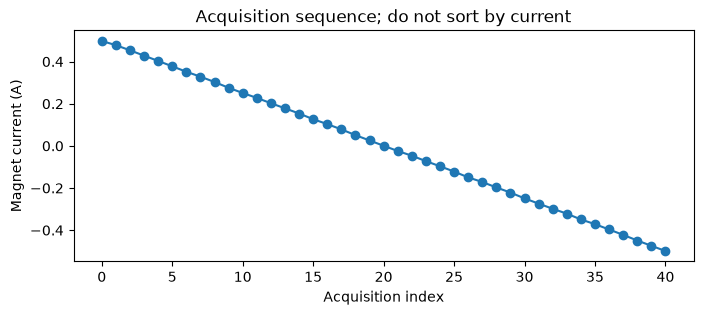

Dark correction: subtract 1 files


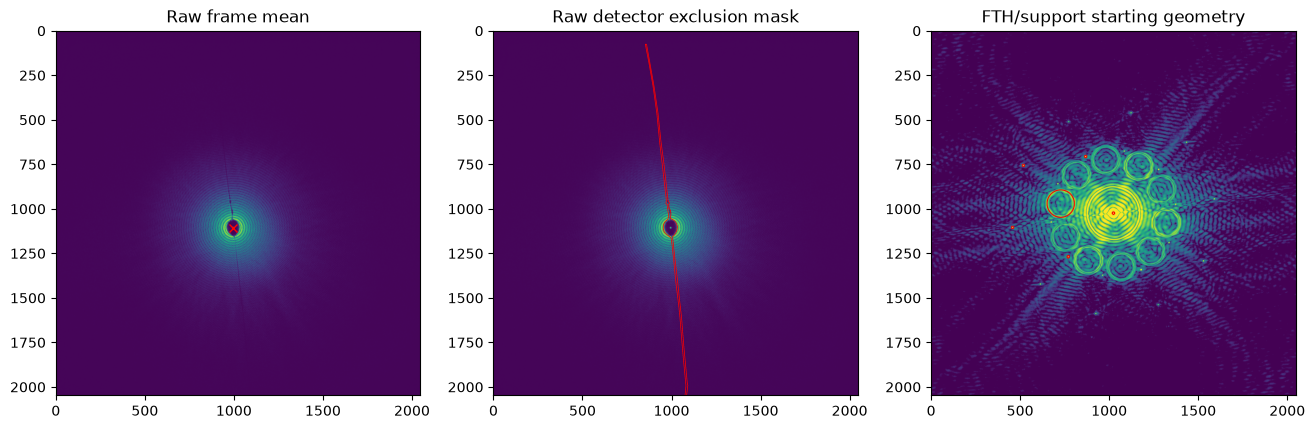

In [27]:
records = inputs.manifest(RAW_ROOT, SCANS)
print("States", len(records), "frames", sorted(set(r["frames"] for r in records)),
      "energy eV", sorted(set(r["energy_ev"] for r in records)))
fig, ax = plt.subplots(figsize=(8,3))
ax.plot([r["current_A"] for r in records], "o-")
ax.set(xlabel="Acquisition index", ylabel="Magnet current (A)", title="Acquisition sequence; do not sort by current")
plt.show()
dark_files = [Path(p) for p in DARK_FILES]
for scan in DARK_SCANS:
    files = sorted((RAW_ROOT/f"2601_xpcs_{scan:05d}"/"marana").glob("*.nx"))
    if not files: raise FileNotFoundError(f"No detector files for configured dark scan {scan}")
    dark_files.extend(files)
print("Dark correction:", f"subtract {len(dark_files)} files" if dark_files else "SKIPPED: no dark files configured")
# Read one state for geometry inspection before processing all states.
raw, saturated, _ = inputs.frame_mean(records[0]["path"], SATURATION)
extra_mask = None if EXTRA_MASK_FILE is None else np.load(EXTRA_MASK_FILE)
source_support = None if SUPPORT_FILE is None else np.load(SUPPORT_FILE)
mask = inputs.detector_mask(raw.shape, DETECTOR_CENTER, BEAMSTOP_RADIUS, WIRE_POLYGONS, extra_mask)|saturated
support_preview = inputs.circles_mask(raw.shape, SUPPORT_CIRCLES) if source_support is None else source_support != 0
fth_preview = abs(np.fft.fftshift(np.fft.fft2(np.where(mask,0,raw))))
fig, axes = plt.subplots(1,3,figsize=(16,5))
axes[0].imshow(np.log1p(raw)); axes[0].plot(DETECTOR_CENTER[1],DETECTOR_CENTER[0],'rx'); axes[0].set_title("Raw frame mean")
axes[1].imshow(np.log1p(raw)); axes[1].contour(mask,levels=[.5],colors='r',linewidths=.5); axes[1].set_title("Raw detector exclusion mask")
axes[2].imshow(np.log1p(fth_preview),vmin=np.percentile(np.log1p(fth_preview),60),vmax=np.percentile(np.log1p(fth_preview),99.7))
axes[2].contour(support_preview,levels=[.5],colors='r',linewidths=.7); axes[2].set_title("FTH/support starting geometry")
plt.show()


In [28]:
# Reload helper edits when rerunning this cell in an existing kernel.
import importlib
importlib.reload(inputs)

config = inputs.prepare_cache(records, CACHE, dark_paths=dark_files,
    center=DETECTOR_CENTER, crop=CROP, binning=BINNING, support_circles=SUPPORT_CIRCLES,
    beamstop_radius=BEAMSTOP_RADIUS, polygons=WIRE_POLYGONS, saturation=SATURATION,
    extra_mask=extra_mask, support_override=source_support,
    align_holograms=ALIGN_HOLOGRAMS, alignment_reference=ALIGNMENT_REFERENCE,
    alignment_max_shift=ALIGNMENT_MAX_SHIFT, alignment_upsample_factor=ALIGNMENT_UPSAMPLE_FACTOR,
    alignment_roi=ALIGNMENT_ROI)
print("Saved", CACHE, "dark subtraction applied:", config["dark"]["applied"])


Prepared 1/41: scan263_point0000
Prepared 2/41: scan263_point0001
Prepared 3/41: scan263_point0002
Prepared 4/41: scan263_point0003
Prepared 5/41: scan263_point0004
Prepared 6/41: scan263_point0005
Prepared 7/41: scan263_point0006
Prepared 8/41: scan263_point0007
Prepared 9/41: scan263_point0008
Prepared 10/41: scan263_point0009
Prepared 11/41: scan263_point0010
Prepared 12/41: scan263_point0011
Prepared 13/41: scan263_point0012
Prepared 14/41: scan263_point0013
Prepared 15/41: scan263_point0014
Prepared 16/41: scan263_point0015
Prepared 17/41: scan263_point0016
Prepared 18/41: scan263_point0017
Prepared 19/41: scan263_point0018
Prepared 20/41: scan263_point0019
Prepared 21/41: scan263_point0020
Prepared 22/41: scan263_point0021
Prepared 23/41: scan263_point0022
Prepared 24/41: scan263_point0023
Prepared 25/41: scan263_point0024
Prepared 26/41: scan263_point0025
Prepared 27/41: scan263_point0026
Prepared 28/41: scan263_point0027
Prepared 29/41: scan263_point0028
Prepared 30/41: scan263

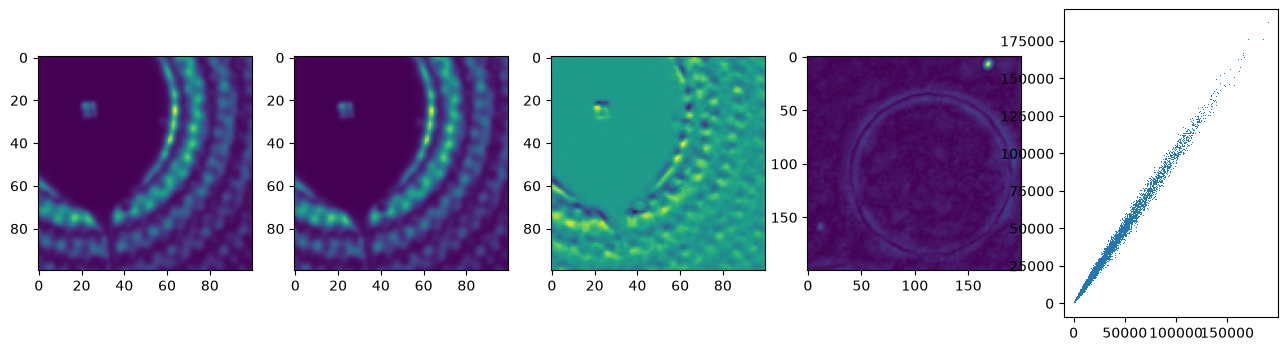

In [38]:
# Read the cache just written above, before plotting comparisons.
with h5py.File(CACHE, "r") as h:
    images = h["holograms"][()]

plt.close("all")
%matplotlib inline

j=38
i=39
from library import fthcore as fth
fig,ax=plt.subplots(1,5, figsize=(16,4))
ax[0].imshow((images[i])[1000:1100,1000:1100])
ax[1].imshow((images[j])[1000:1100,1000:1100])
ax[2].imshow((images[j]-images[i])[1000:1100,1000:1100])
ax[3].imshow(np.abs(fth.reconstruct(images[j]-images[i]))[700:900,700:900])
ax[4].plot((images[i])[1000:1100,1000:1100].flatten(),(images[j])[1000:1100,1000:1100].flatten(), ",")

In [ ]:
with h5py.File(CACHE) as h:
    images=h['holograms'][()]; masks=h['mask_pixel'][()]; support=h['supportmask'][()]
    currents=h['current_A'][()]
    flux=np.sum(np.where(masks,0,images),axis=(1,2))
    excluded=masks.mean(axis=(1,2))
fig, axes=plt.subplots(2,3,figsize=(14,8))
for ax,i in zip(axes[0],[0,len(images)//2,len(images)-1]):
    ax.imshow(np.ma.array(np.log1p(np.maximum(images[i],0)),mask=masks[i]));ax.set_title(f"Point {i}, {currents[i]:+.3f} A")
axes[1,0].imshow(support);axes[1,0].set_title("Retrieval support")
axes[1,1].plot(currents,flux,'o-');axes[1,1].set(xlabel="Current (A)",ylabel="Unmasked camera intensity / s")
axes[1,2].plot(excluded,'o-');axes[1,2].set(xlabel="Acquisition index",ylabel="Excluded fraction")
plt.tight_layout();plt.show()

if ALIGN_HOLOGRAMS:
    with h5py.File(CACHE) as h:
        shifts = h['alignment_shifts_raw_pixels'][()]
        scores = h['alignment_correlation'][()]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(shifts[:, 0], 'o-', label='Row'); axes[0].plot(shifts[:, 1], 'o-', label='Column')
    axes[0].set(xlabel='Acquisition index', ylabel='Applied correction (raw pixels)'); axes[0].legend()
    axes[1].plot(scores[:, 0], 'o-', label='Before'); axes[1].plot(scores[:, 1], 'o-', label='After')
    axes[1].set(xlabel='Acquisition index', ylabel='Normalized cross-correlation'); axes[1].legend()
    plt.tight_layout(); plt.show()

# Plot the cached corrections in detector x/y coordinates, in acquisition order.
with h5py.File(CACHE) as h:
    shifts_xy = h['alignment_shifts_raw_pixels'][()]
    alignment_info = json.loads(h.attrs['config_json'])['alignment']
if alignment_info['enabled']:
    shiftx, shifty = shifts_xy[:, 1], shifts_xy[:, 0]  # column = x, row = y
    indices = np.arange(len(shifts_xy))
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(shiftx, shifty, '-', color='0.65', linewidth=1, zorder=1)
    points = ax.scatter(shiftx, shifty, c=indices, cmap='viridis', zorder=2)
    for index, (sx, sy) in enumerate(zip(shiftx, shifty)):
        ax.annotate(str(index), (sx, sy), xytext=(4, 4), textcoords='offset points', fontsize=8)
    ref_index = alignment_info['reference_index']
    ax.plot(shiftx[ref_index], shifty[ref_index], 'r*', markersize=14,
            label=f'Reference index {ref_index}', zorder=3)
    ax.axhline(0, color='0.8', linewidth=.7, zorder=0)
    ax.axvline(0, color='0.8', linewidth=.7, zorder=0)
    ax.set(xlabel='Applied x shift / column (raw pixels)',
           ylabel='Applied y shift / row (raw pixels)',
           title='Alignment corrections by acquisition index')
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(alpha=.2)
    ax.legend()
    fig.colorbar(points, ax=ax, label='Acquisition index')
    plt.tight_layout(); plt.show()
